In [21]:
import os
from pathlib import Path
from glob import glob
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
import torchvision # Issues installing... resolved!
import cv2 # Not available from current channels.. resolved - conda-forge FTW

# device = 'cuda' if torch.cuda.is_available() else 'cpu'

It looks like you set device to be `cuda` above, but that's an NVidia thing (I think --- at least it's definitely not a mac thing).  You need to use Metal.  I got it to work on my machine.  

In [22]:
# https://developer.apple.com/metal/pytorch/

if torch.backends.mps.is_available():
    mps_device = torch.device("mps")
    x = torch.ones(1, device=mps_device)
    print (x)
else:
    print ("MPS device not found.")

tensor([1.], device='mps:0')


In [23]:
device = torch.device('mps') if torch.backends.mps.is_available() else 'cpu'
SEED = 1984

In [28]:
# page 150 of Ayyadevara and Reddy

PATH = Path('.').absolute().parent
data_dir = PATH / 'data' / 'fruits-360_dataset_100x100'
train_data_dir = data_dir / 'Training'
test_data_dir  = data_dir / 'Test'

In [29]:
train_data_dir

PosixPath('/Users/trobacker/ml_projects/Projects/ImageClassification/data/fruits-360_dataset_100x100/Training')

In [32]:
class fruits_ds(Dataset):
    def __init__(self, folder, apple_type, orange_type):
        apples  = glob(str(folder) + f'/{apple_type}/*')
        oranges = glob(str(folder) + f'/{orange_type}/*')
        self.fpaths = apples + oranges

        # Randomize file paths and create target variables based on the folder corresponding to these file paths
        from random import shuffle, seed
        seed(SEED)
        shuffle(self.fpaths)
        self.targets = [fpath.split('/')[-1].startswith(orange_type) for fpath in self.fpaths] # Orange = 1
    
    def __len__(self): 
        return len(self.fpaths)

    def __getitem__(self, index):
        f = self.fpaths[index]
        target = self.targets[index]
        im = (cv2.imread(f)[:,:,::-1])
        #im = cv2.resize(im, (224,224))
        return torch.tensor(im/255).permute(2,0,1).float().to(device), \
               torch.tensor([target]).float().to(device)

Issue with this now is that 'apples' and 'oranges' are folders not the individual images! 

In [33]:
data = fruits_ds(train_data_dir, 'Apple Braeburn 1', 'Orange 1') #type(data)
data[1]
im, label = data[1]

tensor([0.], device='mps:0')


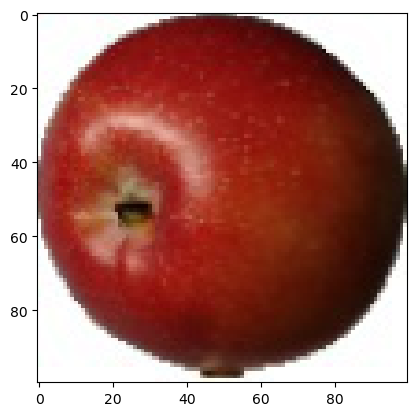

In [34]:
plt.imshow(im.permute(1,2,0).cpu())
print(label)